In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
# Connect database
conn = sqlite3.connect("database/nordicspace.db")

# Read bookings data
df = pd.read_sql("SELECT * FROM bookings_raw", conn)

# -------------------------
# KPI Calculations
# -------------------------
total_revenue = df["total_revenue"].sum()
avg_duration = df["duration_months"].mean()
repeat_rate = df["repeat_customer"].mean() * 100

# Revenue by city
revenue_city = (
    df.groupby("city")["total_revenue"]
    .sum()
    .sort_values(ascending=False)
)

top_city = revenue_city.index[0]

# -------------------------
# Print Results
# -------------------------
print("DESCRIPTIVE ANALYTICS")
print("----------------------------")
print(f"Total Revenue: €{total_revenue:,.2f}")
print(f"Average Rental Duration: {avg_duration:.2f} months")
print(f"Repeat Customer Rate: {repeat_rate:.2f}%")
print(f"Top Performing City: {top_city}")

print("\nRevenue by City:")
print(revenue_city)

conn.close()

DESCRIPTIVE ANALYTICS
----------------------------
Total Revenue: €5,235,900.61
Average Rental Duration: 6.49 months
Repeat Customer Rate: 49.58%
Top Performing City: Helsinki

Revenue by City:
city
Helsinki    1217040.75
Espoo       1205379.32
Vantaa       993261.91
Tampere      921905.83
Turku        898312.80
Name: total_revenue, dtype: float64


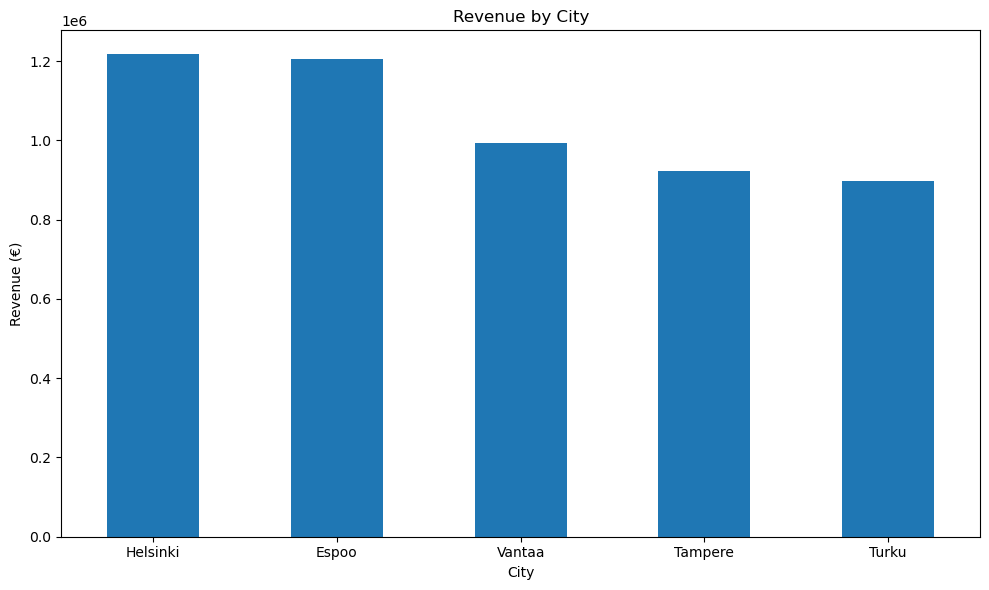

In [2]:


revenue_city.plot(kind="bar", figsize=(10,6))

plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue (€)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("charts/revenue_by_city.png")
plt.show()

Predicted Revenue Next 3 Months:
Month +1: €204,339.44
Month +2: €203,947.40
Month +3: €203,555.35


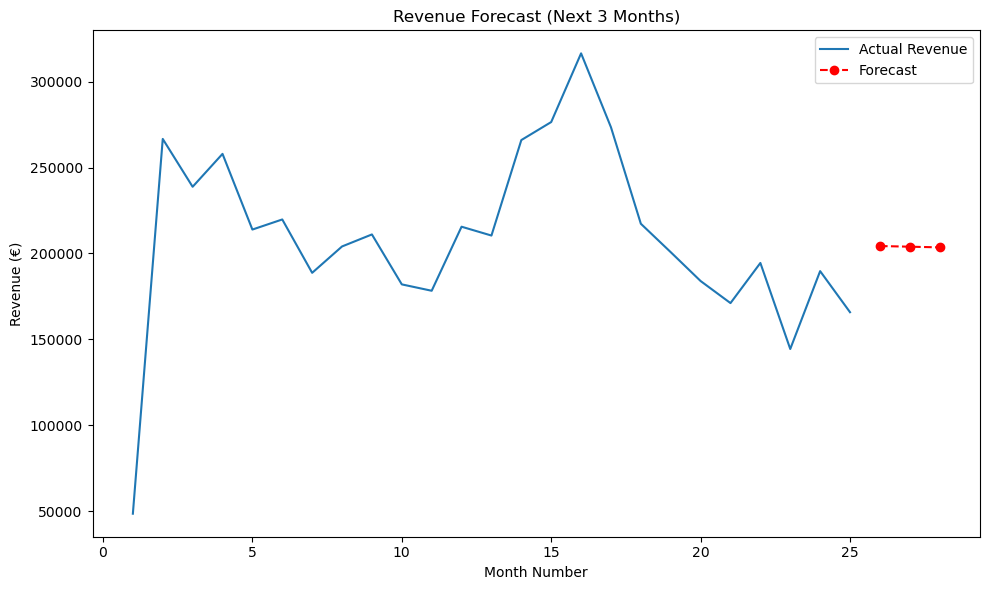

In [3]:
from scipy.stats import linregress

# Connect database
conn = sqlite3.connect("database/nordicspace.db")

df = pd.read_sql("SELECT * FROM bookings_raw", conn)
conn.close()

# Convert date
df["start_date"] = pd.to_datetime(df["start_date"])

# Create monthly revenue
monthly = df.groupby(df["start_date"].dt.to_period("M"))["total_revenue"].sum().reset_index()
monthly["start_date"] = monthly["start_date"].astype(str)

# Add numeric index
monthly["month_num"] = range(1, len(monthly)+1)

# Regression model
x = monthly["month_num"]
y = monthly["total_revenue"]

slope, intercept, r, p, std_err = linregress(x, y)

# Predict next 3 months
future_months = [len(monthly)+1, len(monthly)+2, len(monthly)+3]
future_values = [intercept + slope*i for i in future_months]

print("Predicted Revenue Next 3 Months:")
for i, val in enumerate(future_values, 1):
    print(f"Month +{i}: €{val:,.2f}")

# Plot
plt.figure(figsize=(10,6))
plt.plot(monthly["month_num"], y, label="Actual Revenue")
plt.plot(future_months, future_values, "ro--", label="Forecast")

plt.title("Revenue Forecast (Next 3 Months)")
plt.xlabel("Month Number")
plt.ylabel("Revenue (€)")
plt.legend()
plt.tight_layout()

plt.savefig("charts/revenue_forecast.png")
plt.show()

In [4]:


conn = sqlite3.connect("database/nordicspace.db")
df = pd.read_sql("SELECT * FROM bookings_raw", conn)
conn.close()

# Revenue by city
city_rev = df.groupby("city")["total_revenue"].sum().sort_values(ascending=False)

best_city = city_rev.index[0]
worst_city = city_rev.index[-1]

repeat_rate = df["repeat_customer"].mean() * 100
avg_duration = df["duration_months"].mean()

print("PRESCRIPTIVE ANALYTICS RECOMMENDATIONS")
print("--------------------------------------")

print(f"1. Increase unit capacity in {best_city}, highest revenue location.")
print(f"2. Investigate performance improvement strategy for {worst_city}.")
print(f"3. Launch loyalty campaign (repeat rate = {repeat_rate:.1f}%).")
print(f"4. Promote long-term rental packages (avg stay = {avg_duration:.1f} months).")
print("5. Prepare seasonal pricing strategy for summer peak demand.")

PRESCRIPTIVE ANALYTICS RECOMMENDATIONS
--------------------------------------
1. Increase unit capacity in Helsinki, highest revenue location.
2. Investigate performance improvement strategy for Turku.
3. Launch loyalty campaign (repeat rate = 49.6%).
4. Promote long-term rental packages (avg stay = 6.5 months).
5. Prepare seasonal pricing strategy for summer peak demand.


In [1]:


conn = sqlite3.connect("database/nordicspace.db")
df = pd.read_sql("SELECT * FROM bookings_raw", conn)
conn.close()

df["start_date"] = pd.to_datetime(df["start_date"])
df["month"] = df["start_date"].dt.month

# KPI calculations
kpis = {
    "Total Revenue (€)": df["total_revenue"].sum(),
    "Total Bookings": len(df),
    "Average Rental Duration (Months)": df["duration_months"].mean(),
    "Repeat Customer Rate (%)": df["repeat_customer"].mean() * 100,
    "Average Price per Booking (€)": df["monthly_price"].mean(),
    "Top Performing City": df.groupby("city")["total_revenue"].sum().idxmax(),
    "Highest Revenue Month": df.groupby("month")["total_revenue"].sum().idxmax(),
    "Average Monthly Revenue (€)": df.groupby("month")["total_revenue"].sum().mean()
}

kpi_df = pd.DataFrame(list(kpis.items()), columns=["KPI_Name", "Value"])

kpi_df.to_excel("kpis.xlsx", index=False)

print("kpis.xlsx created successfully")
kpi_df

kpis.xlsx created successfully


,KPI_Name,Value
0,Total Revenue (€),5235900.61
1,Total Bookings,5000
2,Average Rental Duration (Months),6.486
3,Repeat Customer Rate (%),49.58
4,Average Price per Booking (€),161.446816
5,Top Performing City,Helsinki
6,Highest Revenue Month,7
7,Average Monthly Revenue (€),436325.050833


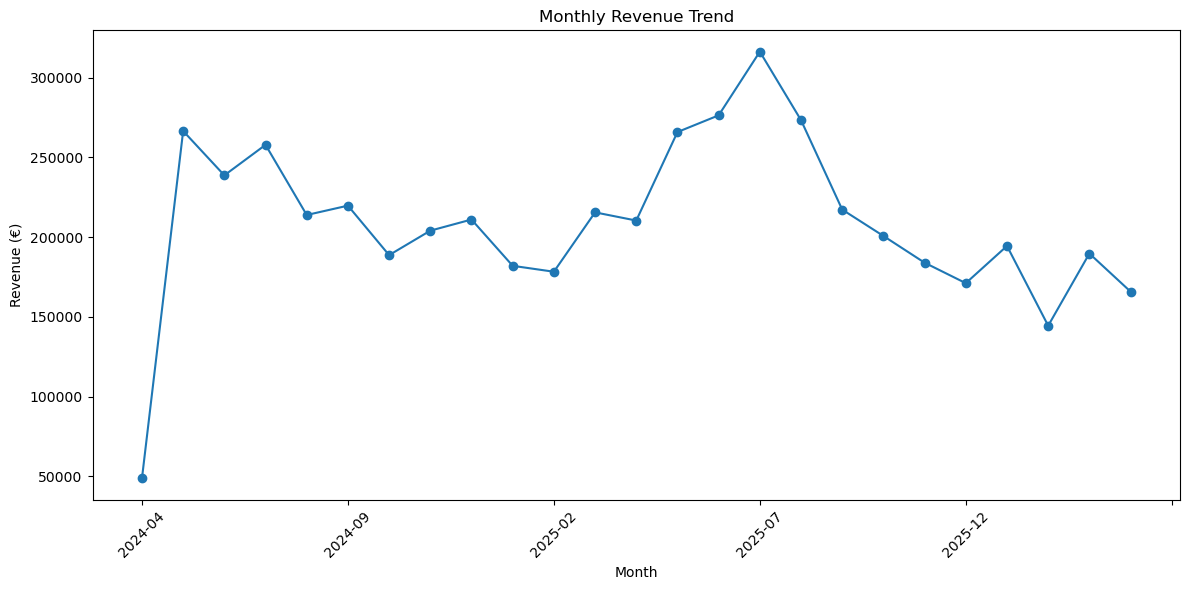

In [2]:


conn = sqlite3.connect("database/nordicspace.db")
df = pd.read_sql("SELECT * FROM bookings_raw", conn)
conn.close()

df["start_date"] = pd.to_datetime(df["start_date"])
df["month_year"] = df["start_date"].dt.to_period("M").astype(str)

monthly = df.groupby("month_year")["total_revenue"].sum()

plt.figure(figsize=(12,6))
monthly.plot(marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (€)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("charts/monthly_revenue.png")
plt.show()

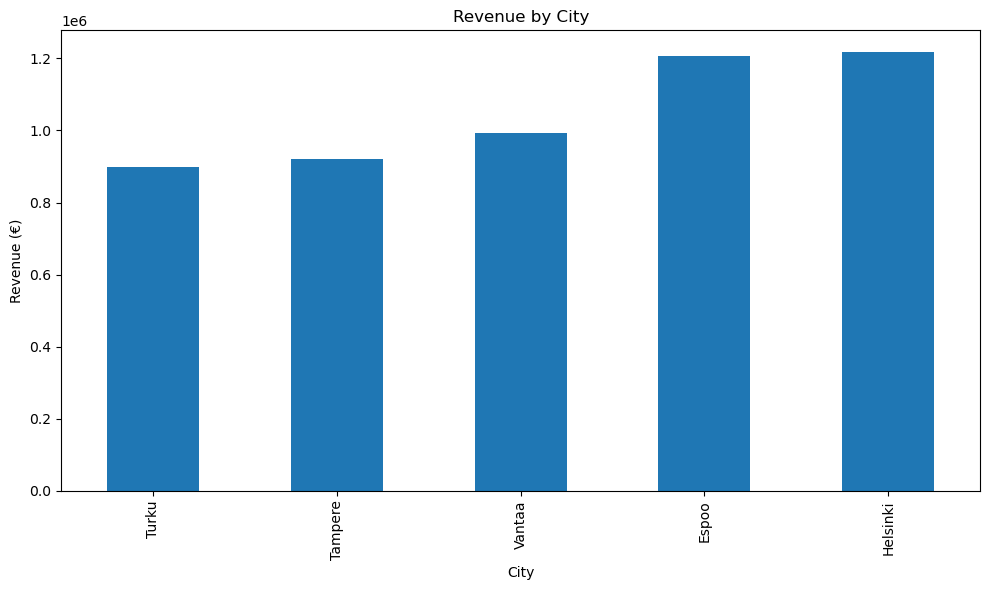

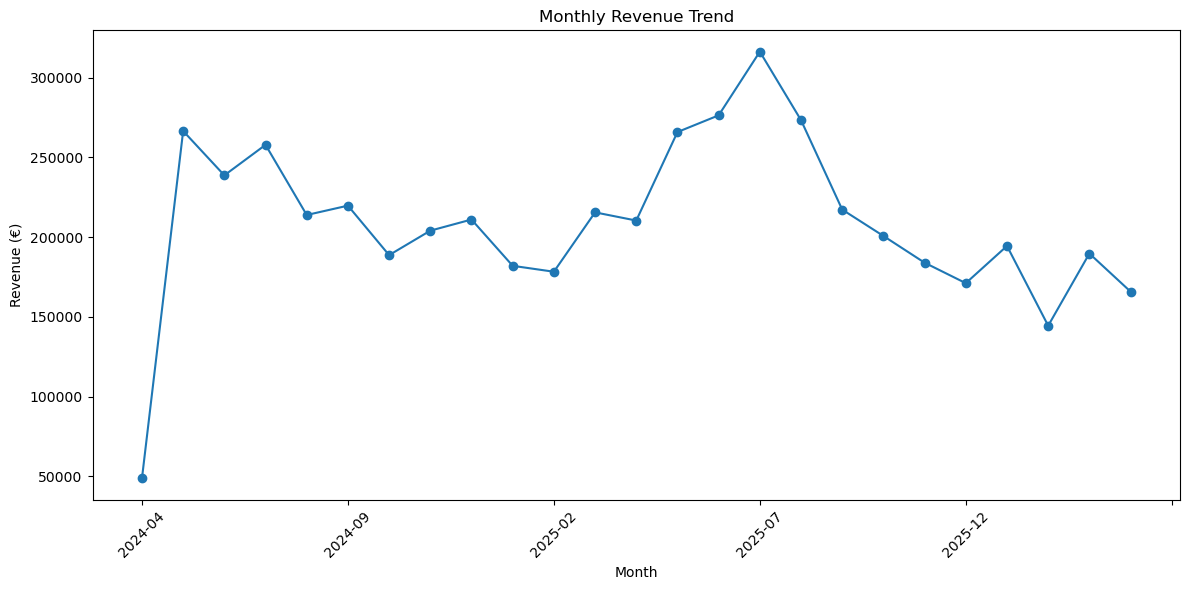

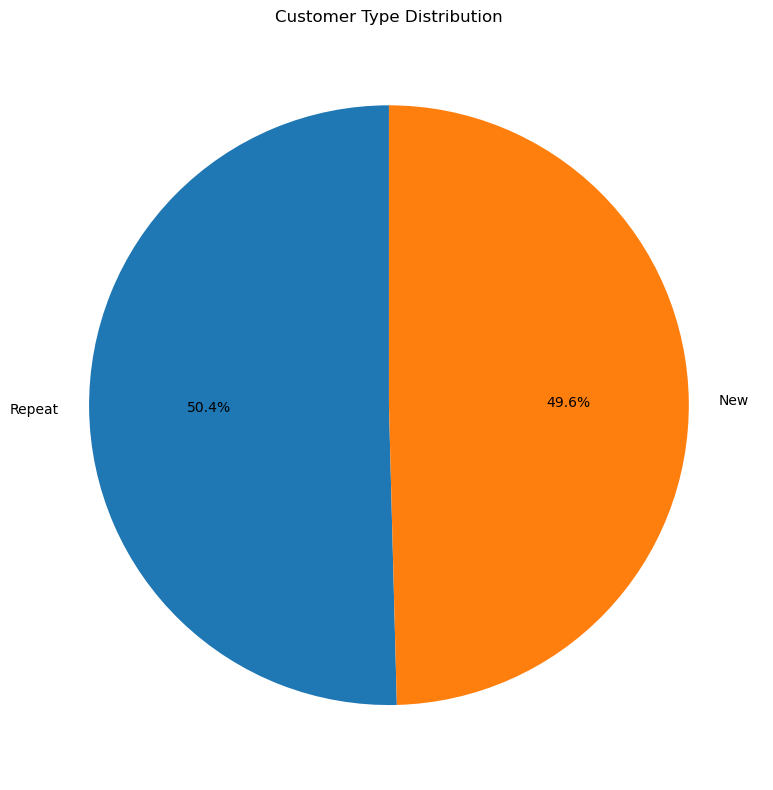

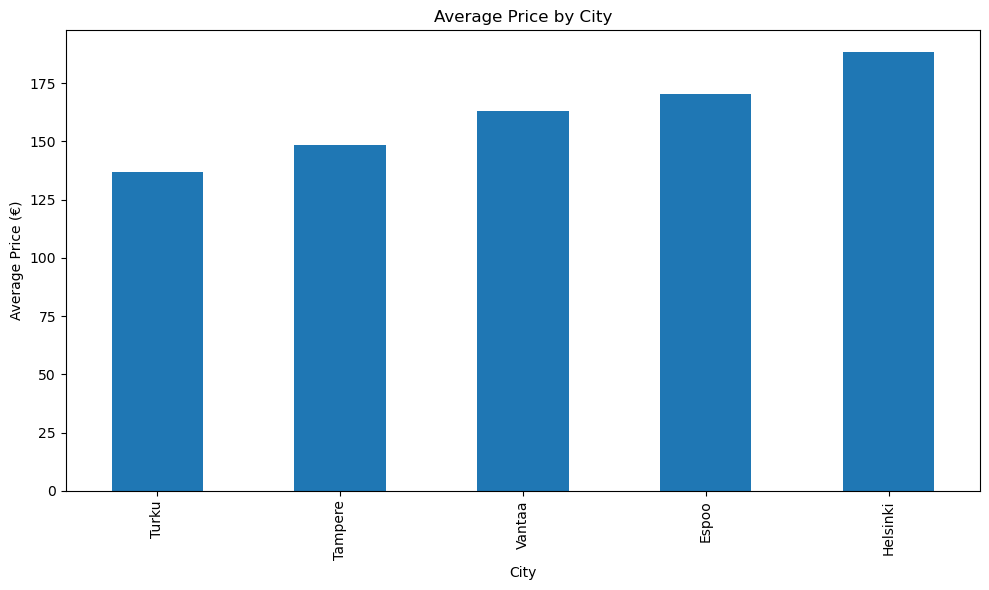

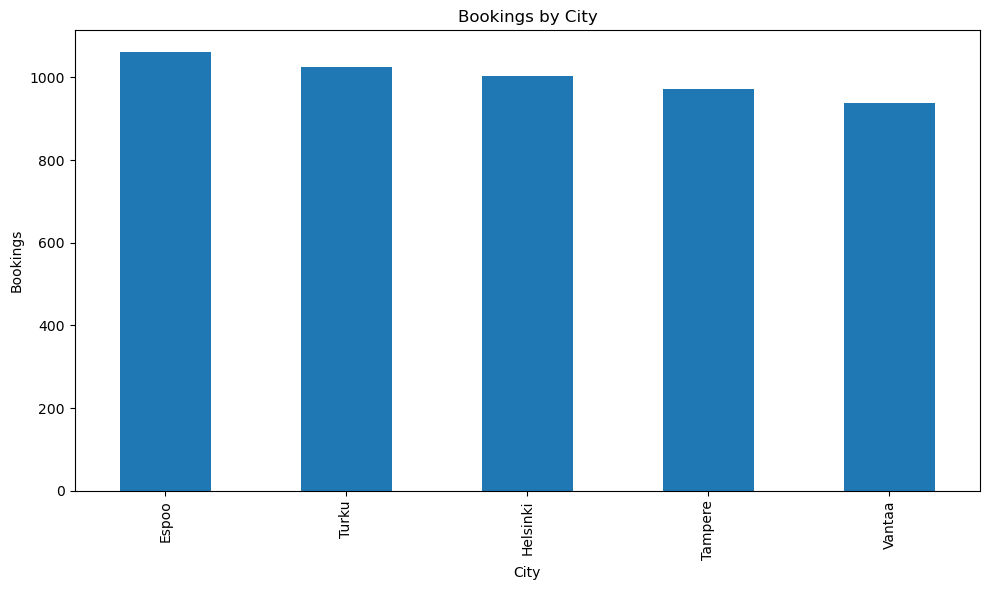

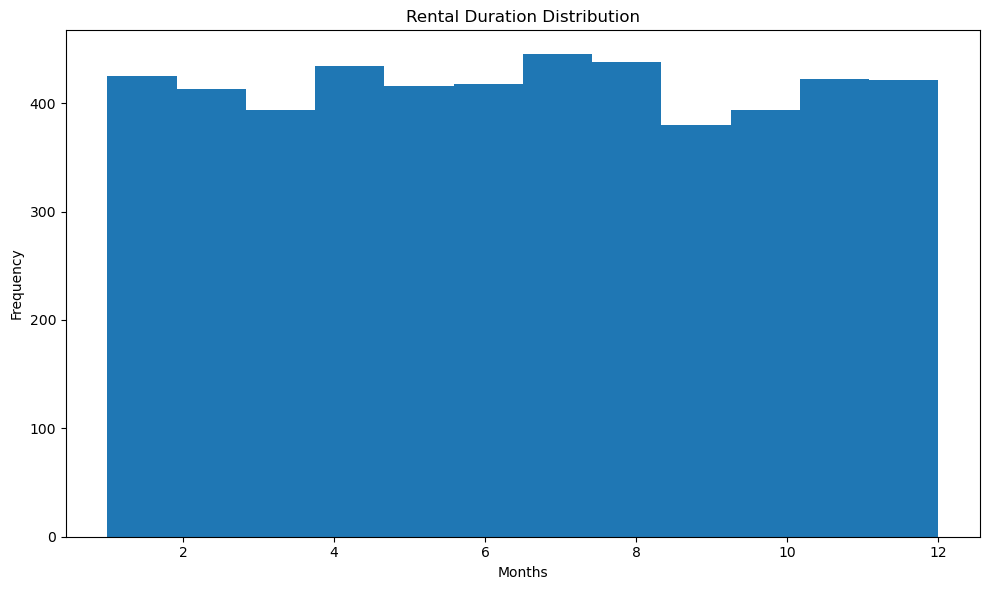

All KPI charts created successfully.


In [3]:

# Load data
conn = sqlite3.connect("database/nordicspace.db")
df = pd.read_sql("SELECT * FROM bookings_raw", conn)
conn.close()

df["start_date"] = pd.to_datetime(df["start_date"])
df["month_year"] = df["start_date"].dt.to_period("M").astype(str)

# ---------------------------------
# 1 Revenue by City
# ---------------------------------
plt.figure(figsize=(10,6))
df.groupby("city")["total_revenue"].sum().sort_values().plot(kind="bar")
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue (€)")
plt.tight_layout()
plt.savefig("charts/revenue_by_city.png")
plt.show()

# ---------------------------------
# 2 Monthly Revenue Trend
# ---------------------------------
plt.figure(figsize=(12,6))
df.groupby("month_year")["total_revenue"].sum().plot(marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (€)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("charts/monthly_revenue.png")
plt.show()

# ---------------------------------
# 3 Repeat Customer Pie
# ---------------------------------
repeat_counts = df["repeat_customer"].value_counts()

plt.figure(figsize=(8,8))
plt.pie(repeat_counts,
        labels=["Repeat", "New"],
        autopct="%1.1f%%",
        startangle=90)
plt.title("Customer Type Distribution")
plt.tight_layout()
plt.savefig("charts/repeat_customer_pie.png")
plt.show()

# ---------------------------------
# 4 Avg Price by City
# ---------------------------------
plt.figure(figsize=(10,6))
df.groupby("city")["monthly_price"].mean().sort_values().plot(kind="bar")
plt.title("Average Price by City")
plt.xlabel("City")
plt.ylabel("Average Price (€)")
plt.tight_layout()
plt.savefig("charts/avg_price_by_city.png")
plt.show()

# ---------------------------------
# 5 Bookings by City
# ---------------------------------
plt.figure(figsize=(10,6))
df["city"].value_counts().plot(kind="bar")
plt.title("Bookings by City")
plt.xlabel("City")
plt.ylabel("Bookings")
plt.tight_layout()
plt.savefig("charts/bookings_by_city.png")
plt.show()

# ---------------------------------
# 6 Rental Duration Histogram
# ---------------------------------
plt.figure(figsize=(10,6))
plt.hist(df["duration_months"], bins=12)
plt.title("Rental Duration Distribution")
plt.xlabel("Months")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("charts/rental_duration_histogram.png")
plt.show()

print("All KPI charts created successfully.")

In [4]:
md = pd.DataFrame({
    "Category": [
        "Measure",
        "Measure",
        "Measure",
        "Measure",
        "Dimension",
        "Dimension",
        "Dimension",
        "Dimension",
        "Dimension"
    ],
    
    "Field_Name": [
        "total_revenue",
        "monthly_price",
        "duration_months",
        "booking_count",
        "city",
        "start_date",
        "month",
        "unit_size",
        "channel"
    ],
    
    "Description": [
        "Total sales revenue",
        "Monthly rental price",
        "Rental duration in months",
        "Number of bookings",
        "Location of booking",
        "Booking start date",
        "Month of booking",
        "Storage unit type",
        "Sales channel source"
    ]
})

md.to_excel("measurements_dimensions.xlsx", index=False)

print("measurements_dimensions.xlsx created successfully")
md

measurements_dimensions.xlsx created successfully


,Category,Field_Name,Description
0,Measure,total_revenue,Total sales revenue
1,Measure,monthly_price,Monthly rental price
2,Measure,duration_months,Rental duration in months
3,Measure,booking_count,Number of bookings
4,Dimension,city,Location of booking
5,Dimension,start_date,Booking start date
6,Dimension,month,Month of booking
7,Dimension,unit_size,Storage unit type
8,Dimension,channel,Sales channel source
